In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [104]:
# Uploading dataset (CSV file)

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('ecommerce_sales_34500.csv')


Saving ecommerce_sales_34500.csv to ecommerce_sales_34500 (3).csv


In [105]:
# First five rows

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [106]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [107]:
# Display all columns for reference

df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [108]:
# Check missing values

df.isnull().sum()

# None found

,0
order_id,0
customer_id,0
product_id,0
category,0
price,0
discount,0
quantity,0
payment_method,0
order_date,0
delivery_time_days,0


In [109]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [110]:
# Converting date column to date time for time analysis
# Before: object (text)
# After: datetime

df['order_date'] = pd.to_datetime(df['order_date'])

In [111]:
# Converting "returned" column by mapping

df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})

In [112]:
# Checking discount values for anomalies (e.g. negatives)

df['discount'].describe()

# Median = 0 -> half of the products apply no discount

,discount
count,34500.000000
mean,0.049291
std,0.069894
min,0.000000
25%,0.000000
50%,0.000000
75%,0.100000
max,0.300000


In [113]:
# Creating a "has_discount" column

df['has_discount'] = df['discount'] > 0

In [114]:
# Converting "has_discount" column by turning boolean text to integer type

df['has_discount'] = df['has_discount'].astype(int)

In [115]:
# Validate the critical numeric columns

numeric_columns = ['price', 'discount', 'quantity', 'total_amount', 'shipping_cost', 'profit_margin']

for column in numeric_columns:
  df[column] = pd.to_numeric(df[column], errors='coerce')

In [116]:
# Final clean dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  int64         
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

In [117]:
df.describe()

,price,discount,quantity,order_date,delivery_time_days,returned,total_amount,shipping_cost,profit_margin,customer_age,has_discount
count,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478272,4.814203,0.055159,170.008494,6.152120,28.116505,43.474377,0.451043
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,3.000000,0.000000,0.820000,0.000000,-6.200000,18.000000,0.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,4.000000,0.000000,19.710000,4.420000,1.500000,31.000000,0.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,5.000000,0.000000,56.820000,6.090000,10.550000,43.000000,0.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,6.000000,0.000000,168.530000,7.830000,33.132500,56.000000,1.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,13.000000,1.000000,12931.800000,15.650000,1536.170000,69.000000,1.000000
std,195.620477,0.069894,0.932270,NaN,1.242141,0.228294,357.503014,2.389539,53.352947,14.980682,0.497605


In [118]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,has_discount
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,0,139.47,7.88,31.17,60,Female,1
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,0,24.73,4.60,-2.62,37,Male,0
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,0,166.80,6.58,13.44,34,Male,1
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,0,63.67,5.50,2.14,21,Female,0
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,0,13.88,2.74,1.15,39,Male,1


In [119]:
# SECTION 1 - DEMOGRAPHICS

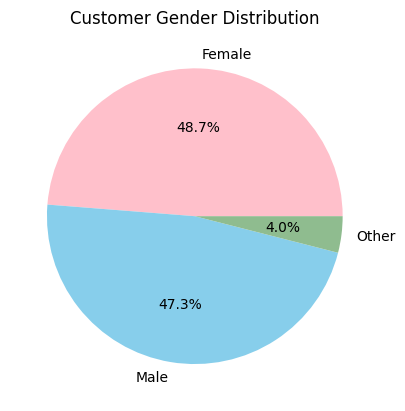

In [120]:
# Gender Distribution Pie Chart

gender_counts = df['customer_gender'].value_counts()

plt.figure()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors = ['pink', 'skyblue', 'darkseagreen'])
plt.title('Customer Gender Distribution')
plt.show()

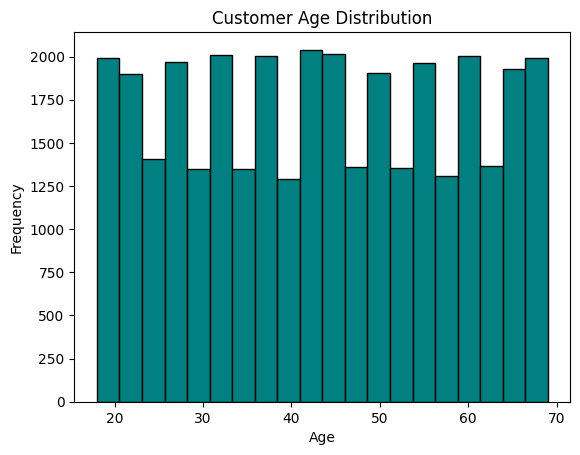

In [121]:
# Age Distribution Histogram

plt.figure()
plt.hist(df['customer_age'], bins=20, color='teal', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Customer Age Distribution')
plt.show()

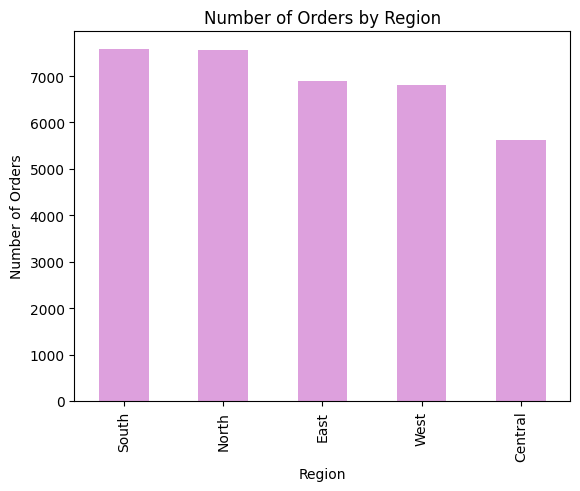

In [122]:
# Order By Region Bar Chart

region_counts = df['region'].value_counts()

plt.figure()
region_counts.plot(kind='bar', color=['plum'])
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Region')
plt.show()


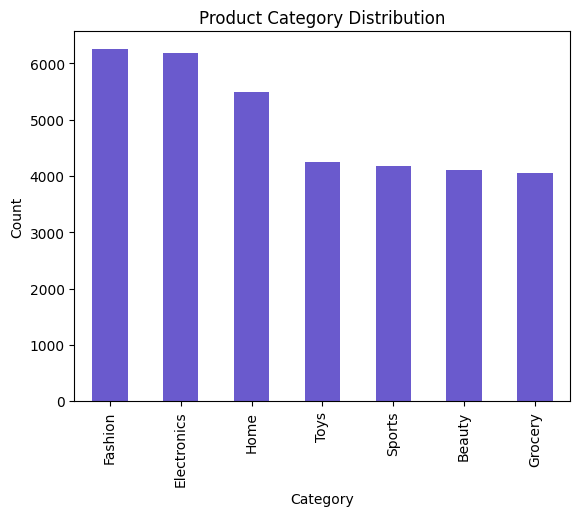

In [123]:
# Product Category Distribution Bar Chart
category_counts = df['category'].value_counts()

plt.figure()
category_counts.plot(kind='bar', color=['slateblue'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Product Category Distribution')
plt.show()


In [124]:
# SECTION 2 - Exploring Variables

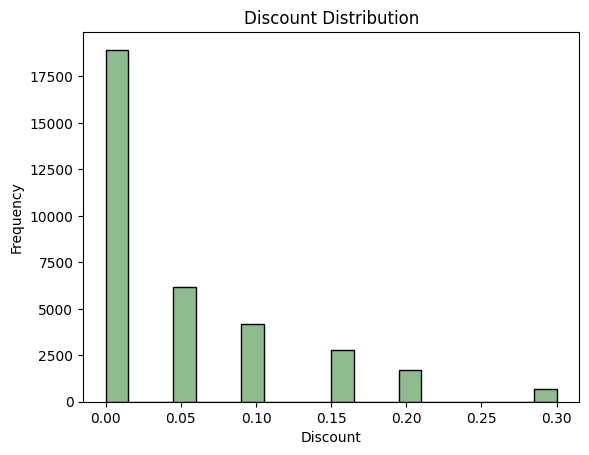

In [125]:
# Discount Distribution Histogram

plt.figure()
plt.hist(df['discount'], bins=20, color='darkseagreen', edgecolor='black')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.title('Discount Distribution')
plt.show()

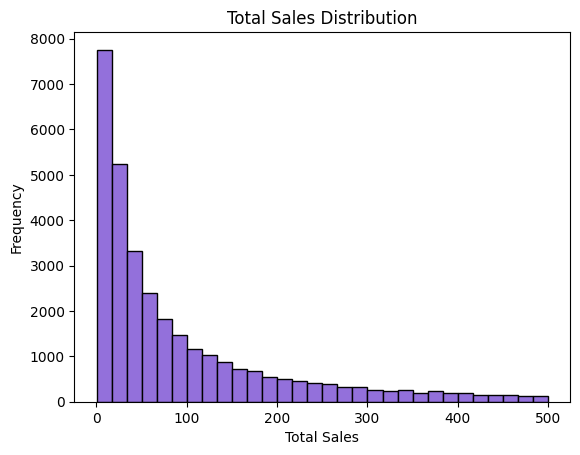

In [126]:
# Total Sales Distribution

filtered = df[df['total_amount'] < 500]

plt.figure()
plt.hist(filtered['total_amount'], bins=30, color='mediumpurple', edgecolor='black')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.title('Total Sales Distribution')
plt.show()


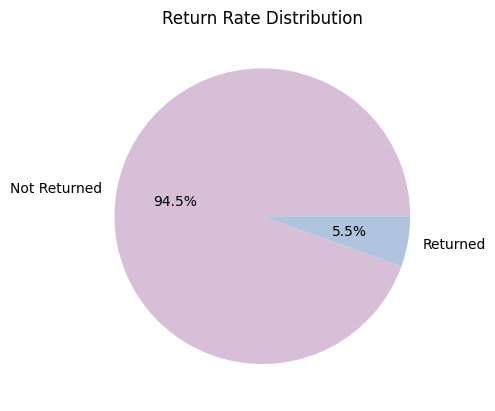

In [127]:
# Returns Distribution Pie Chart

return_counts = df['returned'].value_counts()

plt.figure()
plt.pie(return_counts, labels=['Not Returned', 'Returned'], autopct='%1.1f%%', colors = ['thistle', 'lightsteelblue'])
plt.title('Return Rate Distribution')
plt.show()

In [128]:
#SECTION 3 - Core Comparisons

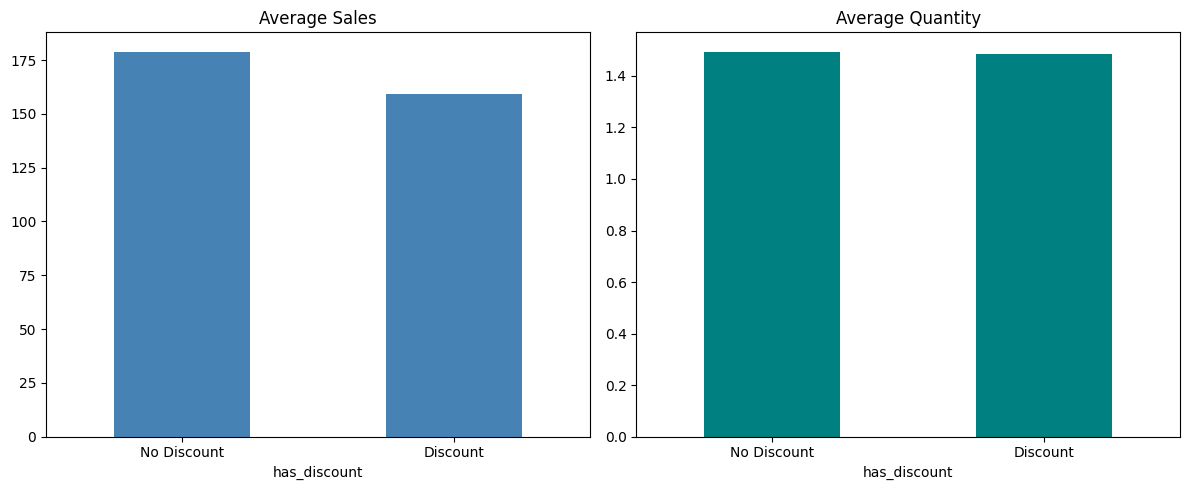

In [129]:
# Discount VS Sales Bar Charts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sales Chart
discount_comparison['total_amount'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Average Sales')
ax1.set_xticklabels(['No Discount', 'Discount'], rotation=0)

# Quantity Chart
discount_comparison['quantity'].plot(kind='bar', ax=ax2, color='teal')
ax2.set_title('Average Quantity')
ax2.set_xticklabels(['No Discount', 'Discount'], rotation=0)

plt.tight_layout()
plt.show()


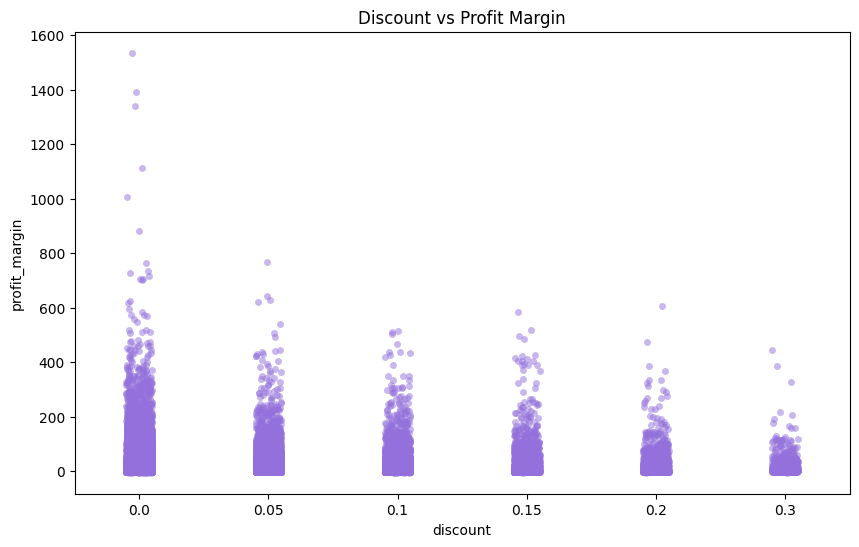

In [130]:
# Discount VS Profit Scatter Plot

plt.figure(figsize=(10, 6))
sns.stripplot(x='discount', y='profit_margin', data=df,
              color='mediumpurple', alpha=0.5, jitter=True)
plt.title('Discount vs Profit Margin')
plt.show()

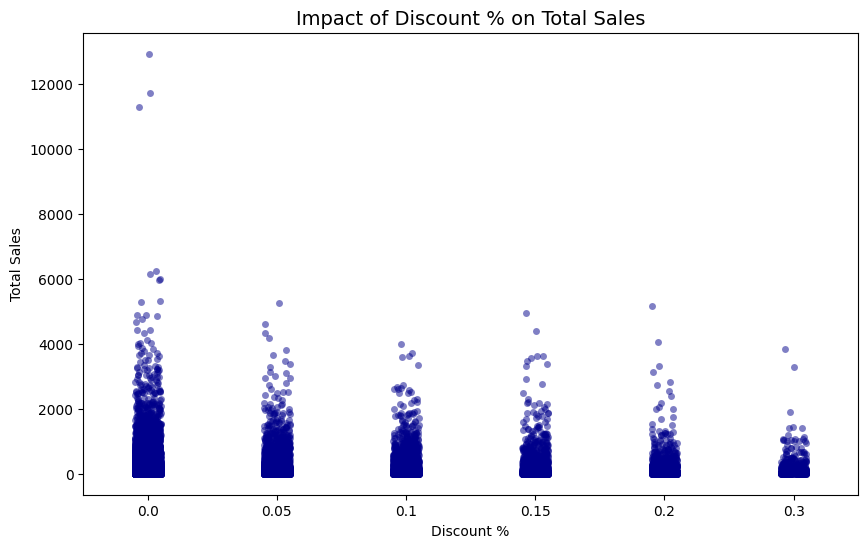

In [131]:
# Discount VS Sales Scatter Plot

plt.figure(figsize=(10, 6))
sns.stripplot(x='discount', y='total_amount', data=df, color='darkblue', alpha = 0.5, jitter = True)

plt.title('Impact of Discount % on Total Sales', fontsize=14)
plt.xlabel('Discount %')
plt.ylabel('Total Sales')
plt.show()

<Figure size 640x480 with 0 Axes>

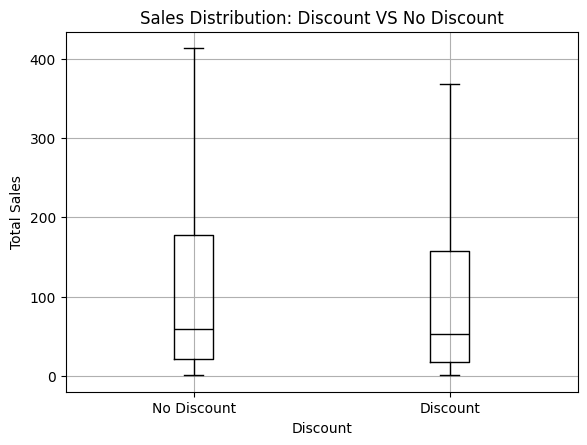

In [132]:
# Discount VS Sales Box Plot

plt.figure()
df.boxplot(column='total_amount', by='has_discount', color ='black', showfliers=False)
plt.xlabel('Discount')
plt.xticks([1, 2], ['No Discount', 'Discount'])
plt.ylabel('Total Sales')
plt.suptitle("")
plt.title('Sales Distribution: Discount VS No Discount')
plt.show()

In [133]:
# SECTION 4 - Advanced Comparisons

<Figure size 640x480 with 0 Axes>

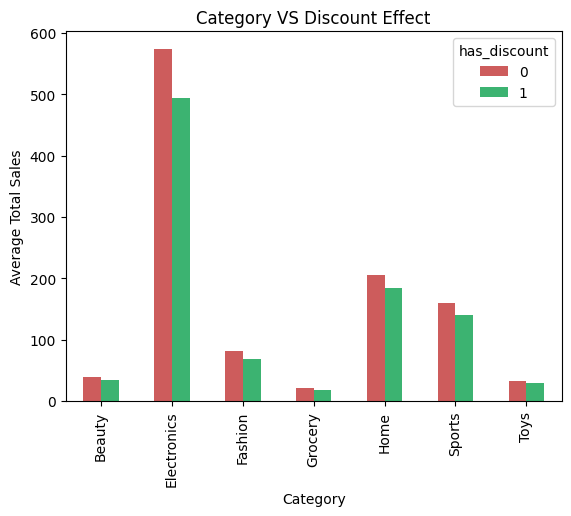

In [134]:
# Category VS Discount Effect Multi-bar Chart

cat_discount = df.groupby(['category', 'has_discount'])['total_amount'].mean().unstack()

plt.figure()
cat_discount.plot(kind='bar', color=["indianred", "mediumseagreen"])
plt.title("Category VS Discount Effect")
plt.xlabel("Category")
plt.ylabel("Average Total Sales")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

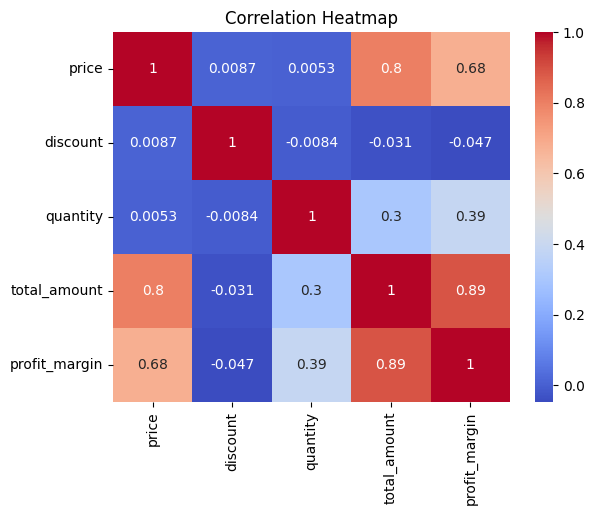

In [135]:
# Overall Correlation Heatmap

plt.figure()
corr = df[['price', 'discount', 'quantity', 'total_amount', 'profit_margin']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show

In [136]:
# Section 5 - Hypothesis Testing

In [140]:
# Group A: Orders with a discount
discounted_sales = df[df['has_discount'] == 1]['total_amount']

# Group B: Orders without a discount
non_discounted_sales = df[df['has_discount'] == 0]['total_amount']

# Independent Samples T-Test
t_stat, p_val = stats.ttest_ind(discounted_sales, non_discounted_sales, equal_var=False)

# Display the results
print("Statistical Test Results:")
print(f"Test Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

alpha = 0.05

if p_val < alpha:
    print("\nDecision: Reject the Null Hypothesis.")
    print("Conclusion: Discounts have a significant impact on sales, supporting the main hypothesis.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no significant evidence that discounts impact sales in this dataset.")

Statistical Test Results:
Test Statistic: -5.2177
P-value: 0.0000

Decision: Reject the Null Hypothesis.
Conclusion: Discounts have a significant impact on sales, supporting the main hypothesis.
